# Data Ingestion & Inspection

In this initial phase, we load the raw dataset into our environment and perform a high-level structural audit. Before diving into statistical analysis, it is essential to understand the "anatomy" of the data. This block focuses on inspecting data dimensions, identifying column types (numerical vs. categorical), checking for missing values, and verifying memory usage to ensure the data is complete and structurally sound.

In [1]:
import os
import sys

# Navigate up from 'notebooks' and append the core project directory to the system path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

In [ ]:
# Import all the necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.utils import create_chart

In [3]:
# Read the dataset
mortgage_data = pd.read_csv('../data/mortgage_loan_dataset.csv')
# Show the first 5 rows of the dataset to look at the data 
mortgage_data.head()

,Gender,Age,Married,Education,Job,Employment Years,Annual Income (USD),Interest Rate,Down Payment (USD),Credit Score,Existing Monthly Debt (USD),Area,Loans Repaid,Max Loan Amount (USD)
0,Male,36,Yes,PhD,Software Engineer,13,134183.86,0.08,101706.78,682,2045.80,Urban,3,498842.67
1,Female,63,No,High School,Freelancer,37,68884.95,0.03,46324.29,823,804.73,Suburban,10,536232.53
2,Female,33,Yes,PhD,Nurse,11,76396.27,0.03,13045.79,813,1050.54,Urban,0,518884.47
3,Female,51,Yes,Bachelor's,Business Owner,29,115968.80,0.05,60388.40,752,904.08,Rural,2,757940.14
4,Male,53,Yes,Bachelor's,Nurse,27,99977.38,0.06,54838.14,728,2285.76,Rural,1,283110.21


In [4]:
# # Check data types, non-null counts, and memory usage of the mortgage dataset
mortgage_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 49990 entries, 0 to 49989
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Gender                       49990 non-null  str    
 1   Age                          49990 non-null  int64  
 2   Married                      49990 non-null  str    
 3   Education                    49990 non-null  str    
 4   Job                          49990 non-null  str    
 5   Employment Years             49990 non-null  int64  
 6   Annual Income (USD)          49990 non-null  float64
 7   Interest Rate                49990 non-null  float64
 8   Down Payment (USD)           49990 non-null  float64
 9   Credit Score                 49990 non-null  int64  
 10  Existing Monthly Debt (USD)  49990 non-null  float64
 11  Area                         49990 non-null  str    
 12  Loans Repaid                 49990 non-null  int64  
 13  Max Loan Amount (USD)      

The dataset contains 49,990 rows and 14 columns with no missing values, requiring no data cleaning for nulls. It consists of 9 numerical features and 5 categorical features (str), which will require encoding before training any machine learning models.

In [5]:
# Count the number of unique values in each column to identify categorical variables or constants
mortgage_data.nunique()

Gender                             2
Age                               59
Married                            2
Education                          4
Job                               12
Employment Years                  51
Annual Income (USD)            49660
Interest Rate                     10
Down Payment (USD)             48413
Credit Score                     271
Existing Monthly Debt (USD)    45521
Area                               3
Loans Repaid                      25
Max Loan Amount (USD)          49976
dtype: int64

The nunique() output reveals 5 categorical features with low cardinality, including binary variables (Gender, Married) and specific groupings for Area (3) and Education (4). Among the 9 numerical features, financial columns like Annual Income are highly continuous, while Interest Rate is restricted to 10 fixed tiers and Loans Repaid tracks 25 distinct values instead of a simple binary indicator.

In [6]:
# Count missing (null) values in each column to assess data completeness
mortgage_data.isnull().sum()

Gender                         0
Age                            0
Married                        0
Education                      0
Job                            0
Employment Years               0
Annual Income (USD)            0
Interest Rate                  0
Down Payment (USD)             0
Credit Score                   0
Existing Monthly Debt (USD)    0
Area                           0
Loans Repaid                   0
Max Loan Amount (USD)          0
dtype: int64

In [7]:
# Check the total number of duplicate rows across the entire dataset
mortgage_data.duplicated().sum().item()

0

# Exploratory Data Analysis

With a firm understanding of the dataset's structure, we transition to Exploratory Data Analysis. In this section, we use descriptive statistics and visual plots (such as histograms, boxplots, and heatmaps) to uncover hidden patterns, trends, and anomalies. We will analyze target distribution, identify and evaluate statistical outliers, and investigate linear relationships between features to guide our feature engineering and modeling decisions.

In [8]:
# Generate summary statistics (mean, min, max, quartiles) for numeric columns
mortgage_data.describe()

,Age,Employment Years,Annual Income (USD),Interest Rate,Down Payment (USD),Credit Score,Existing Monthly Debt (USD),Loans Repaid,Max Loan Amount (USD)
count,49990.000000,49990.000000,49990.000000,49990.000000,49990.000000,49990.000000,49990.000000,49990.000000,4.999000e+04
mean,57.046609,32.068234,120323.418437,0.050957,64296.936887,760.373195,1656.598654,5.825545,6.634191e+05
std,16.947352,15.171406,36965.115132,0.020815,39594.864102,63.385441,751.032649,3.431778,3.126811e+05
min,28.000000,0.000000,25000.000000,0.030000,5000.000000,580.000000,0.000000,0.000000,2.614254e+04
25%,42.000000,19.000000,95011.170000,0.030000,34152.762500,717.000000,1099.917500,3.000000,4.254228e+05
50%,57.000000,34.000000,119978.225000,0.050000,59097.870000,764.000000,1564.655000,5.000000,6.232435e+05
75%,72.000000,48.000000,145455.785000,0.060000,87905.060000,811.000000,2140.255000,8.000000,8.641049e+05
max,86.000000,50.000000,274740.320000,0.120000,250000.000000,850.000000,5000.000000,24.000000,2.270836e+06


The output shows a high-income, creditworthy applicant pool, with a mean Annual Income of $120,323 and an excellent average Credit Score of 760 (ranging from a fair 580 to a perfect 850). The data represents an older, established demographic (average Age of 57 with up to 50 Employment Years) securing substantial funding, as indicated by a mean Max Loan Amount of $663,419 and a healthy average Down Payment of $64,297.

In [9]:
# Convert the target variable to an integer to optimize memory and data types
mortgage_data['Max Loan Amount (USD)'] = mortgage_data['Max Loan Amount (USD)'].astype('int64')

# Separate the target variable 'y' for future model training
y = mortgage_data['Max Loan Amount (USD)']
y

0        498842
1        536232
2        518884
3        757940
4        283110
          ...  
49985    995780
49986    659523
49987    354407
49988    713931
49989    688714
Name: Max Loan Amount (USD), Length: 49990, dtype: int64

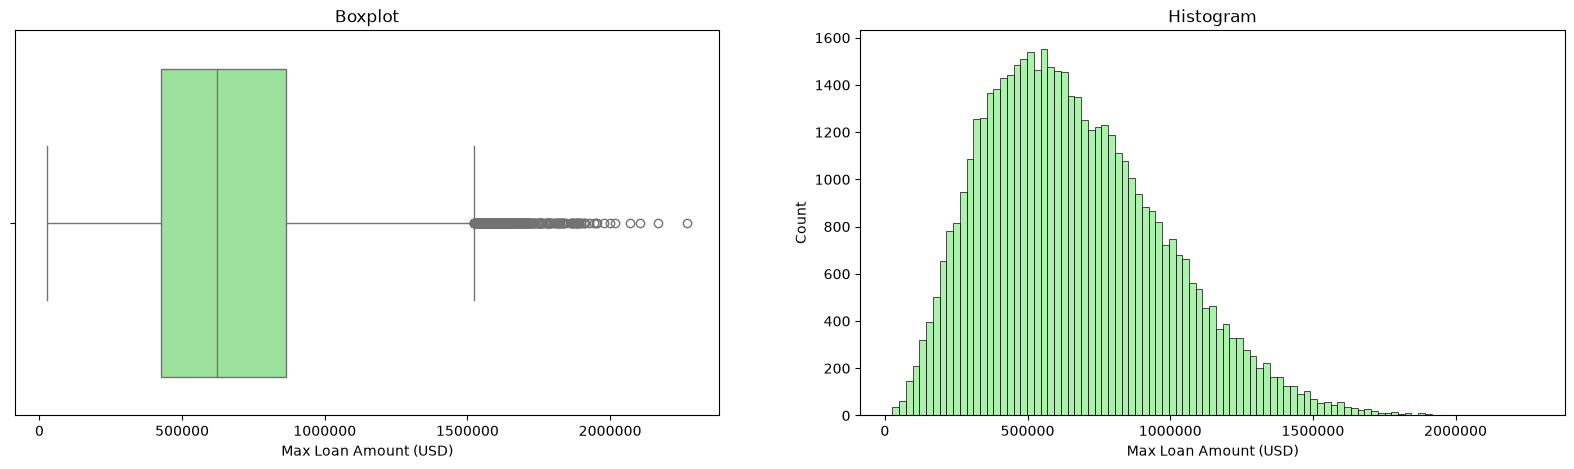

In [10]:
# Set up a side-by-side subplot figure to visualize the target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(20, 5))

# Plot 1: Boxplot to identify outliers and median distribution
sns.boxplot(data=mortgage_data, x=y, ax=axes[0], color='lightgreen')
axes[0].ticklabel_format(style='plain', axis='x')  # Disable scientific notation (e.g., 1e6)
axes[0].set_title('Boxplot')

# Plot 2: Histogram to evaluate data frequency and skewness
sns.histplot(data=mortgage_data, x=y, ax=axes[1], color='lightgreen')
axes[1].ticklabel_format(style='plain', axis='x')  # Disable scientific notation
axes[1].set_title('Histogram')

plt.show()


The plots show a right-skewed distribution for Max Loan Amount (USD). The distribution peaks between 500,000 and 600,000 USD. The boxplot reveals a long right tail. It highlights numerous upper-bound outliers exceeding 1.5 million USD. The plots show a right-skewed distribution for Max Loan Amount (USD) with a long right tail and numerous outliers exceeding 1.5 million USD. Due to this severe skewness, the median is a better measure of central tendency than the mean, which is artificially inflated by these high-value loans.

In [11]:
# Generate rounded summary statistics for the target variable to analyze its distribution scales
y.describe().round(0)

count      49990.0
mean      663419.0
std       312681.0
min        26142.0
25%       425422.0
50%       623243.0
75%       864105.0
max      2270835.0
Name: Max Loan Amount (USD), dtype: float64

The statistics mathematically confirm the right-skew seen in the charts, as the mean ($663,419) is pulled significantly higher than the median ($623,243) by extreme upper-bound outliers. The maximum value of $2,270,835 sits far past the 75th percentile ($864,105). This validates using the median for central tendency.

In [12]:
# Calculate the Interquartile Range (IQR) to identify statistical outliers
q1 = y.quantile(0.25)
q3 = y.quantile(0.75)

iqr = q3 - q1

# Define the upper boundary for outliers (values beyond this are considered anomalies)
upper_whisker = q3 + 1.5 * iqr

# Count the exact number of outlier rows that exceed the upper whisker limit
y.where(y > upper_whisker).count().item()

413

The IQR method mathematically confirms the visual evidence, identifying exactly 413 upper-bound outliers that exceed the upper whisker threshold of $1,522,129.50. These extreme values account for less than 1% of the dataset (0.83%), proving that while they heavily skew the mean and create a long right tail on the charts, they represent a small group of exceptionally high-value loan profiles.

In [13]:
# Identify and list all numeric columns (integers and floats) for subsequent feature processing
numeric_cols = mortgage_data.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_cols

['Age',
 'Employment Years',
 'Annual Income (USD)',
 'Interest Rate',
 'Down Payment (USD)',
 'Credit Score',
 'Existing Monthly Debt (USD)',
 'Loans Repaid',
 'Max Loan Amount (USD)']

In [14]:
# Identify and list all text-based categorical columns for encoding and feature engineering
categorical_cols = mortgage_data.select_dtypes(include='str').columns.tolist()
categorical_cols

['Gender', 'Married', 'Education', 'Job', 'Area']

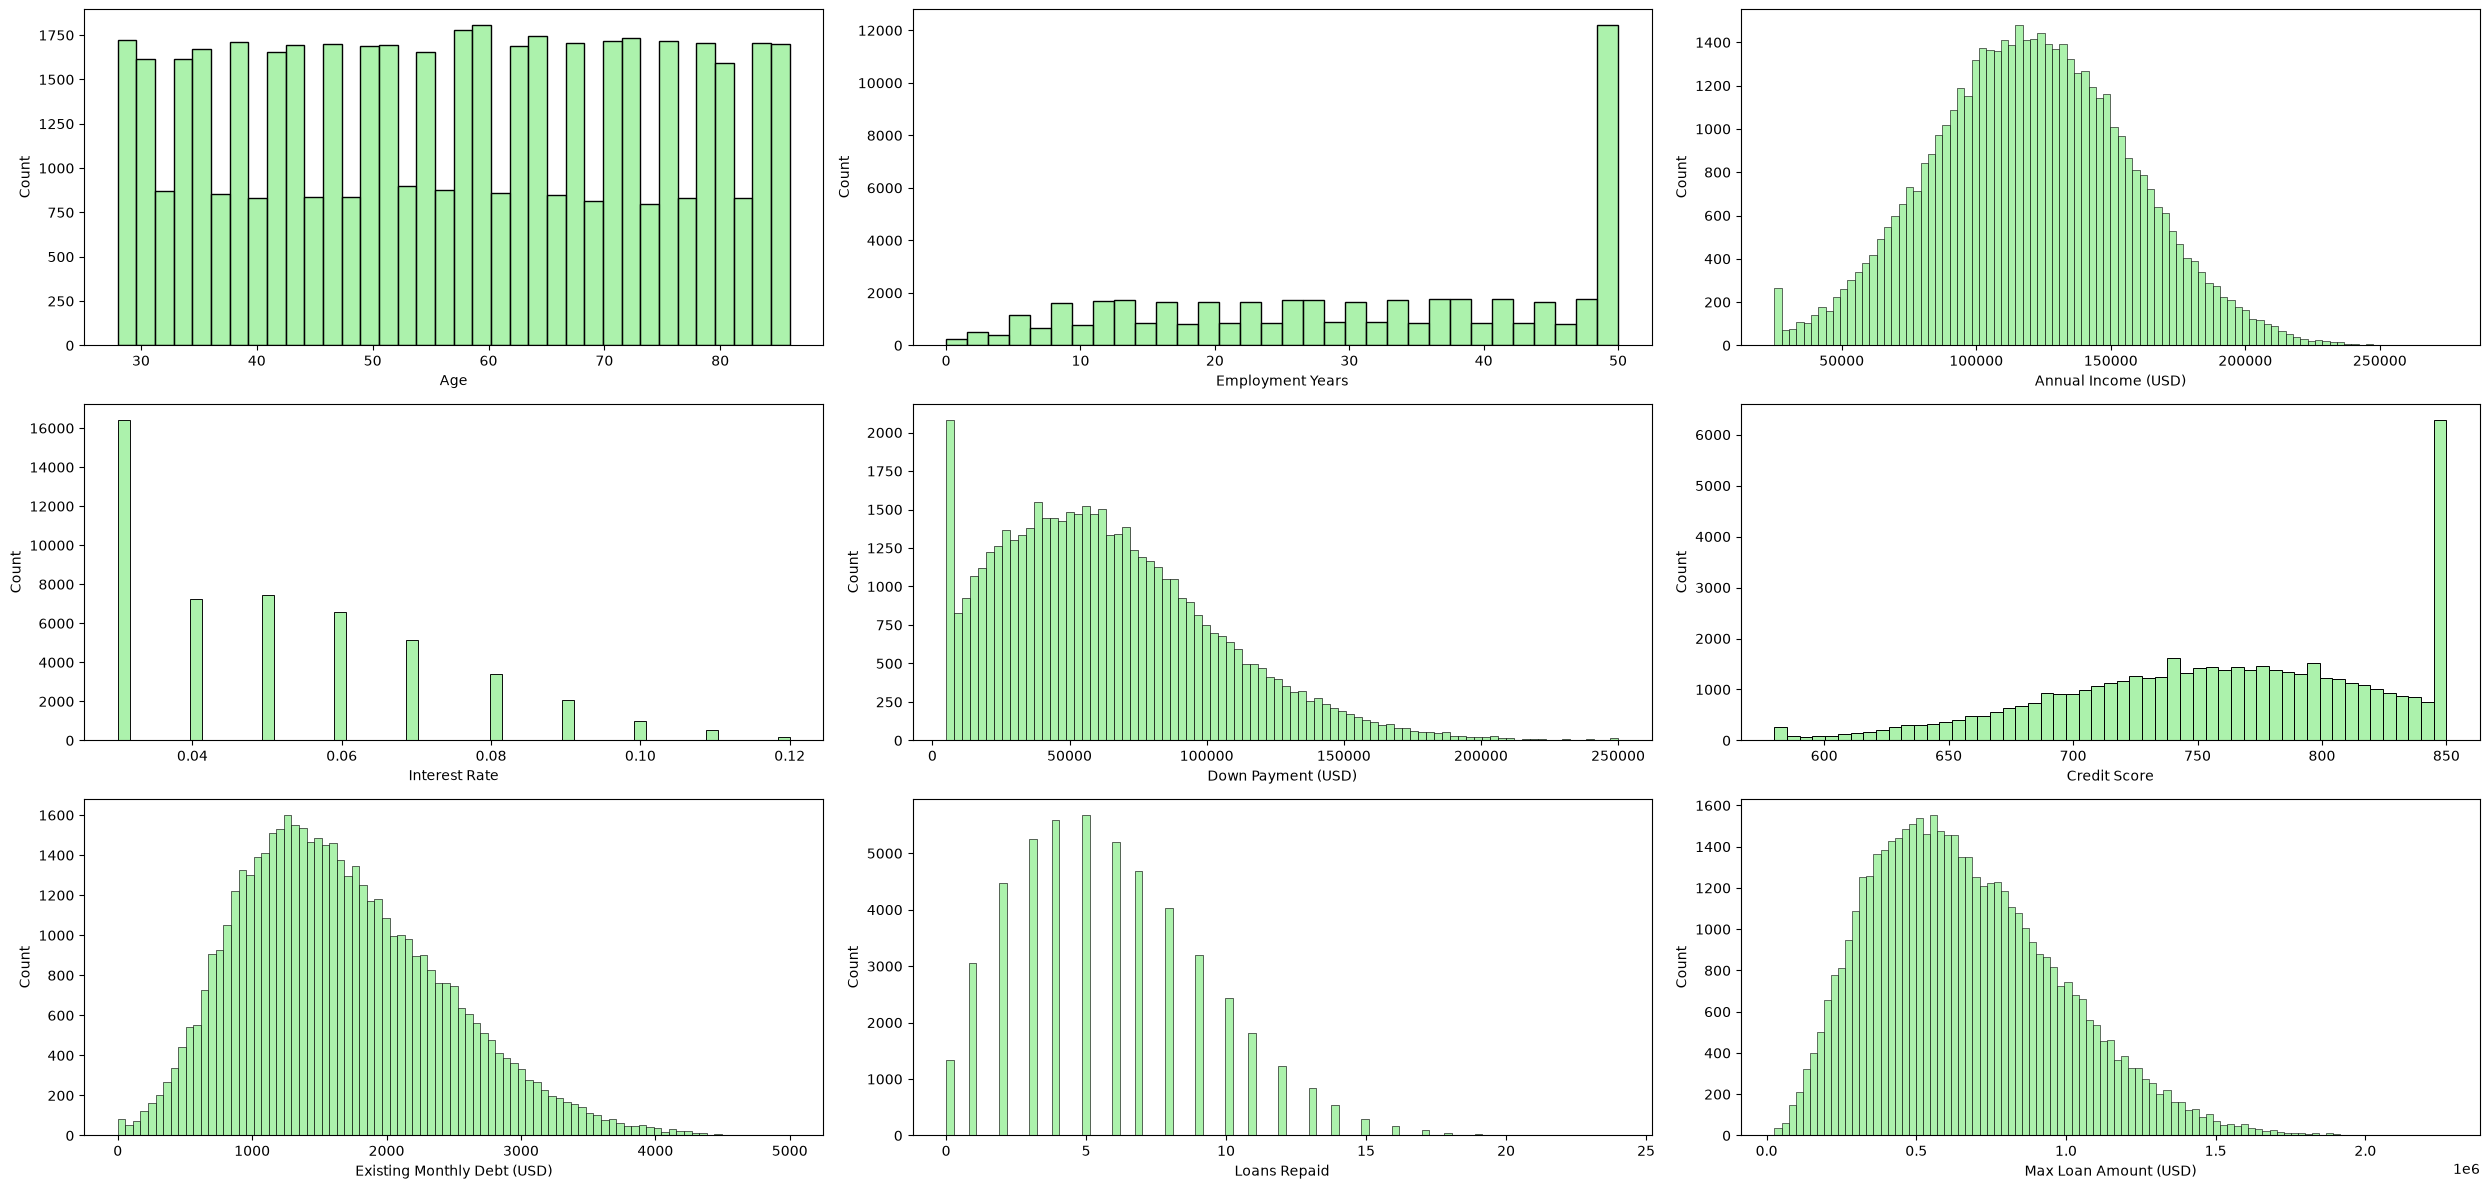

In [15]:
# Execute the charting function to visualize distributions for all numerical features
create_chart(mortgage_data, numeric_cols, sns.histplot)

The generated grid confirms the visual profiles for all 9 numerical features, highlighting specific patterns for preprocessing:
- Uniform & Capped Distributions: Age is perfectly uniform. Employment Years is also uniform but features a massive spike at the 50-year mark, indicating the data is capped at this maximum threshold.
- Normal & Left-Skewed Distributions: Annual Income follows a clean, symmetric normal distribution. Conversely, Credit Score is left-skewed with a significant accumulation of perfect 850 scores at the maximum boundary.
- Right-Skewed Financial Metrics: Down Payment, Existing Monthly Debt, and Max Loan Amount display classic right-skewed behaviors with long upper tails, confirming the need for logarithmic scaling.
- Discrete Tiers: Interest Rate and Loans Repaid show clean, isolated vertical bars, reflecting their discrete integer or fixed-percentage nature.

Key Data Insights:
- Data Capping: The massive spikes at 50 Employment Years and an 850 Credit Score show that the data is artificially capped at these maximum limits, masking the true variance of top-tier applicants.
- Structural Disconnect: While Annual Income is perfectly normally distributed, loan-related metrics are heavily right-skewed, proving that an elite, highly leveraged group of borrowers qualifies for exponentially larger loans.
- Rigid Policy & Clean Sampling: The sharp spikes in Interest Rate reveal a strict, rules-based corporate pricing matrix, while the perfectly uniform Age distribution indicates the dataset was deliberately balanced to avoid age bias.

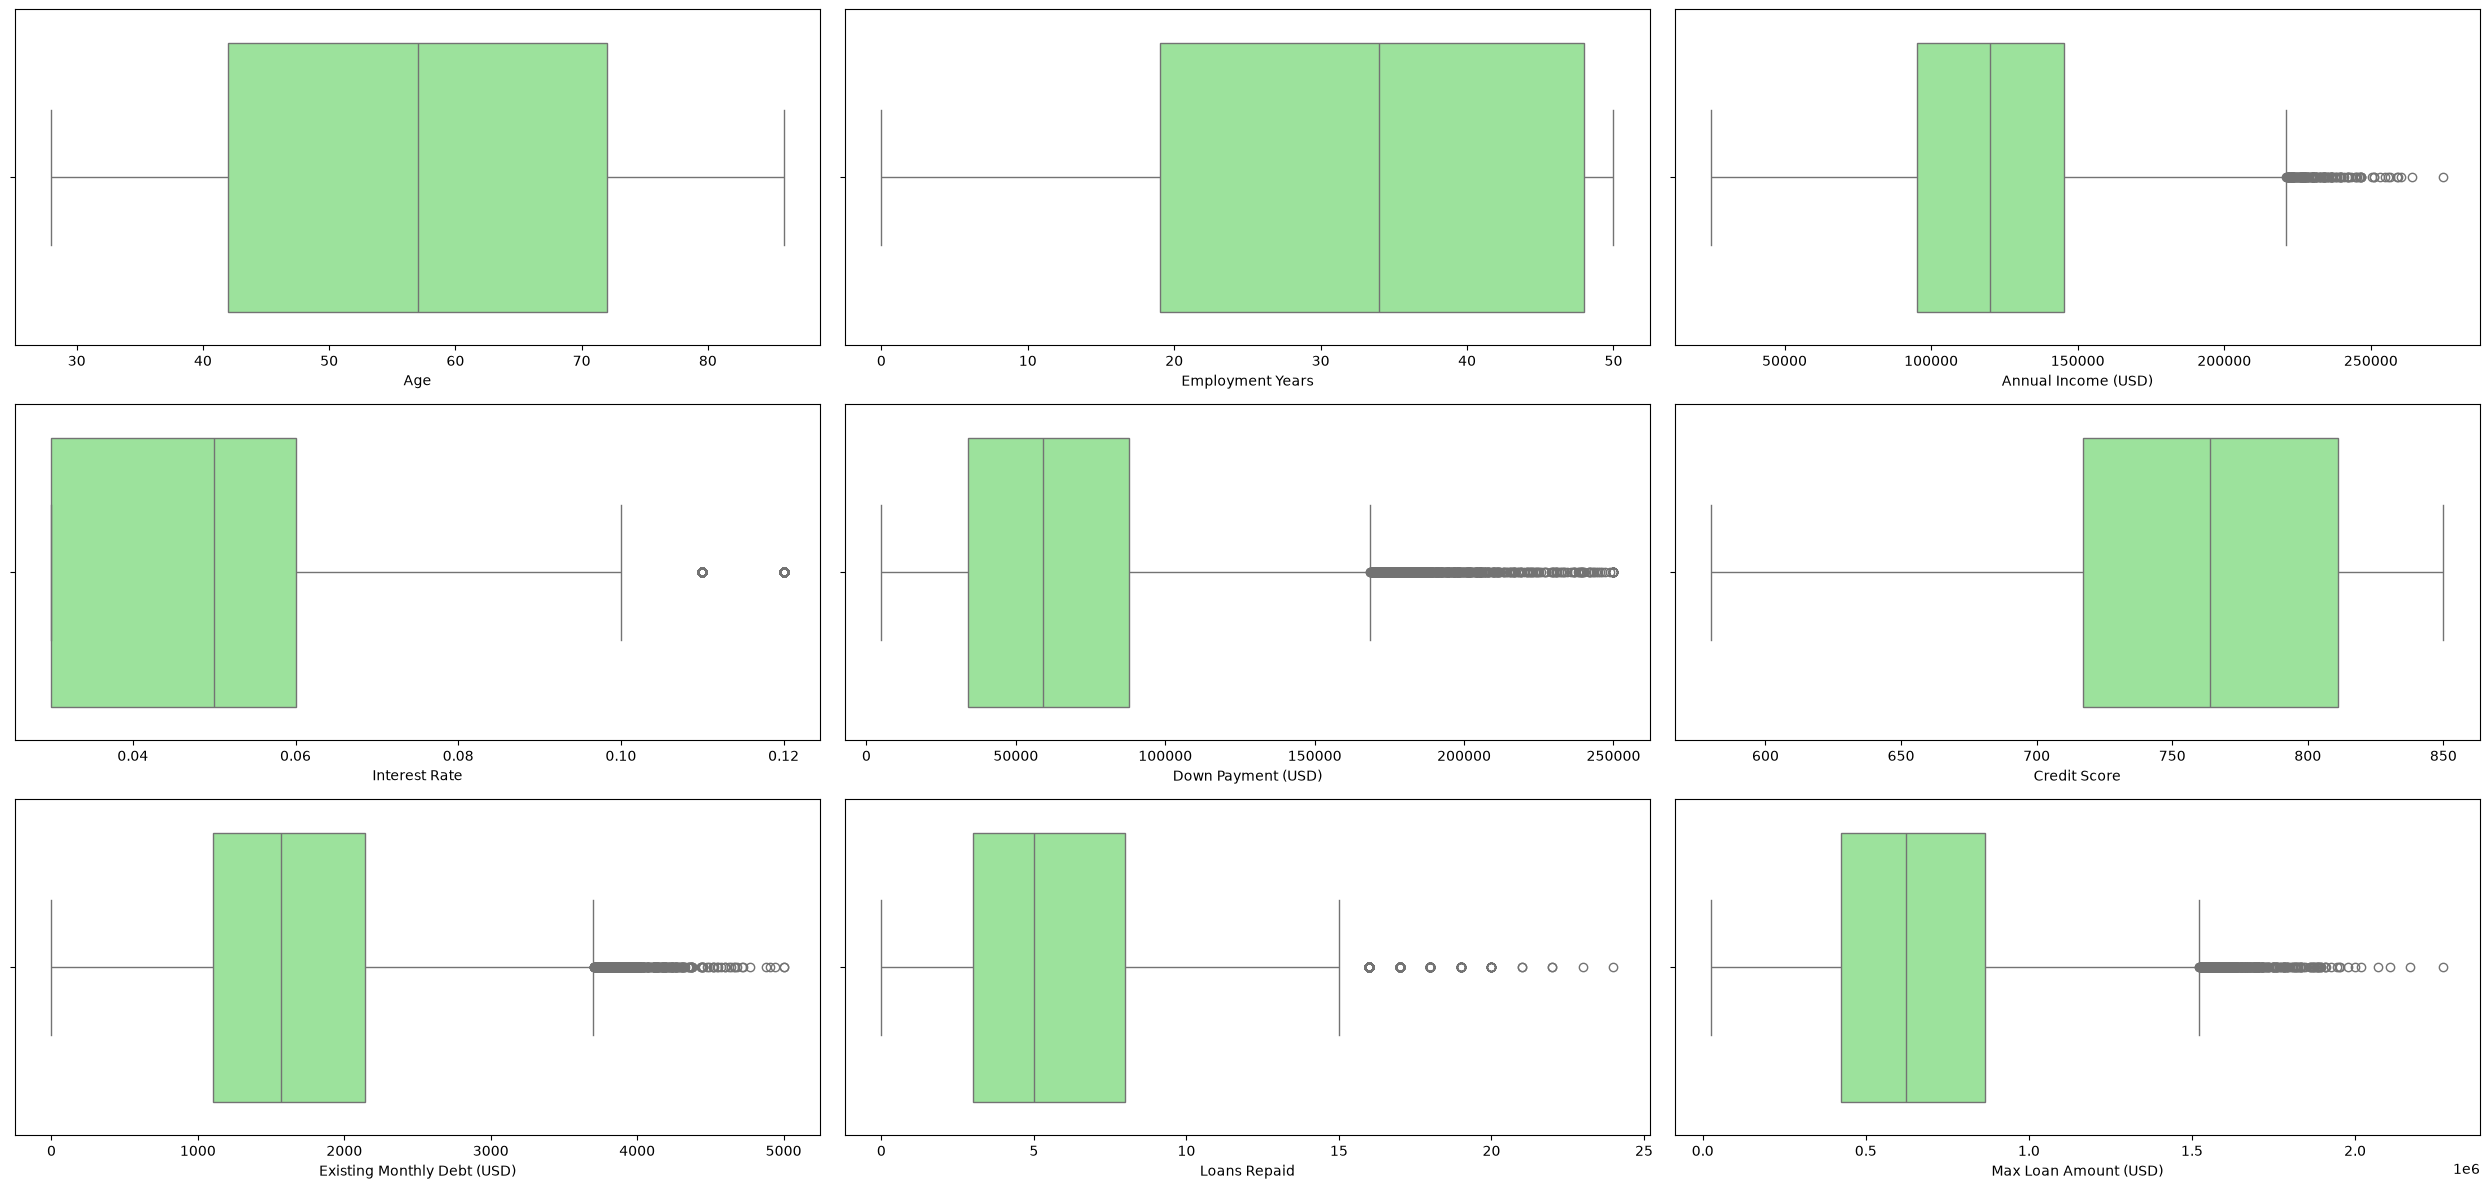

In [16]:
# Execute the charting function to generate boxplots for all numerical features to spot outliers
create_chart(mortgage_data, numeric_cols, sns.boxplot)

These boxplots visually represent the distribution, symmetry, and outlier presence across your 9 numerical features:
1. Symmetrical & Well-Behaved Features:
- Age & Employment Years: Perfectly centered medians with zero statistical outliers. This confirms their uniform distributions, though Employment Years shows its right-hand box wall pinned tightly against the 50-year upper whisker limit (confirming the data capping).
- Credit Score: Completely free of outliers, showing a broad interquartile range (IQR) spanning mostly from ~715 to ~810. The distribution is incredibly stable for statistical modeling.

2. Heavily Outlier-Ridden Features (Right-Skewed):
- Annual Income, Down Payment, Existing Monthly Debt, & Max Loan Amount: Every single one of these financial columns features a tight green IQR box crushed to the left, followed by an extensive, dense trail of black outlier dots stretching far out to the right.
- Loans Repaid: Shows a small cluster of extreme outliers spanning from 15 to 24 past loans, standing completely isolated from the standard borrower pool.

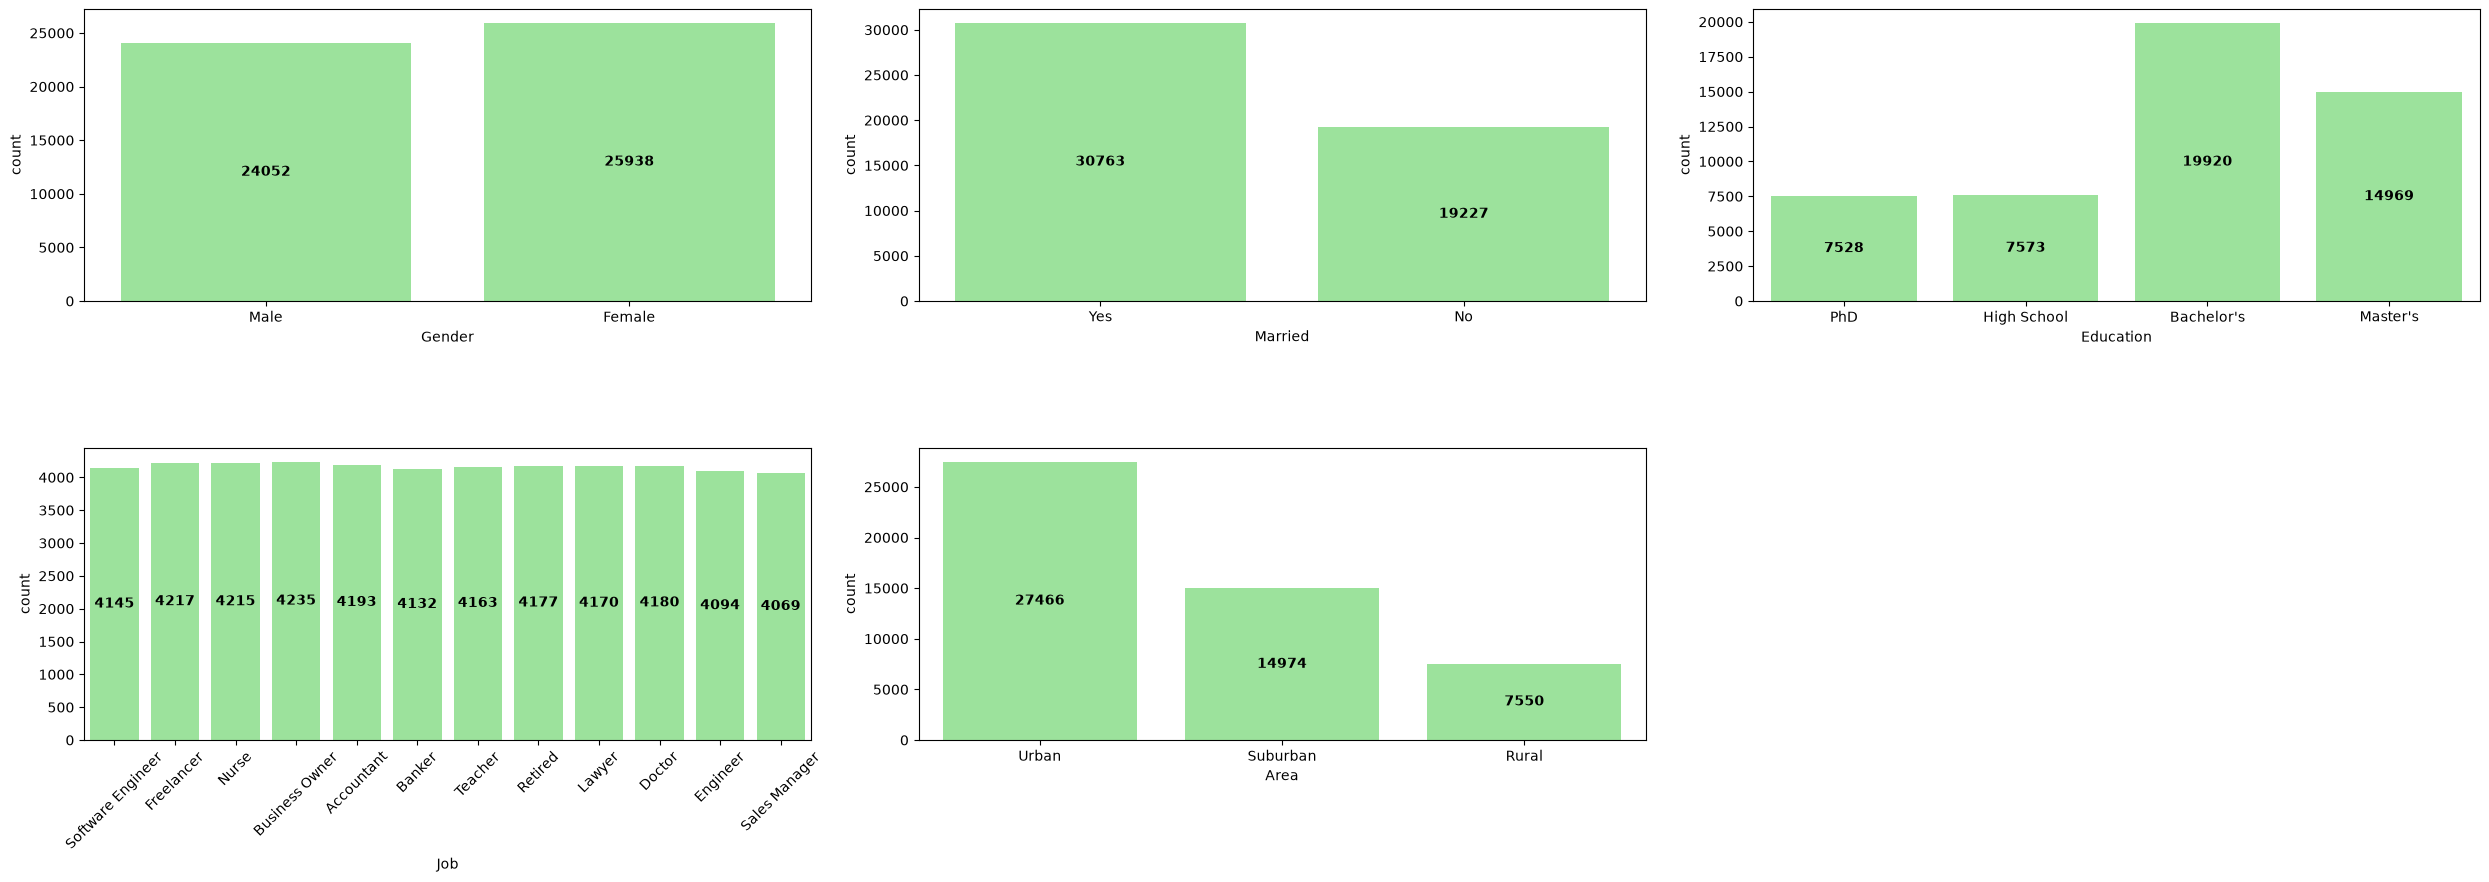

In [17]:
# Execute the charting function with count plots to see the frequency distribution of categorical features
create_chart(mortgage_data, categorical_cols, sns.countplot)

The bar charts display the distribution of your 5 categorical features:
- Gender: Perfectly balanced dataset with roughly equal splits between Men (24,052) and Women (25,938). This completely eliminates any risk of gender bias in your models.
- Married: Married applicants (30,763) heavily outnumber single applicants (19,227), reflecting a more stable or family-oriented borrower pool.
- Education: The applicant base is highly educated. Holders of a Bachelor's (19,920) or Master's (14,969) degree dominate the dataset, while PhD and High School graduates form smaller, identically sized cohorts (~7,500 each).
- Job: The distribution across all 12 professions is perfectly flat and uniform (hovering steadily around 4,100 people per job). This mathematically proves that the data was intentionally balanced or stratified during collection.
- Area: A clear step-down trend is visible. Most applicants reside in Urban areas (27,466), followed by half that amount in Suburban regions (14,074), and a minor segment in Rural zones (7,550).

<Axes: >

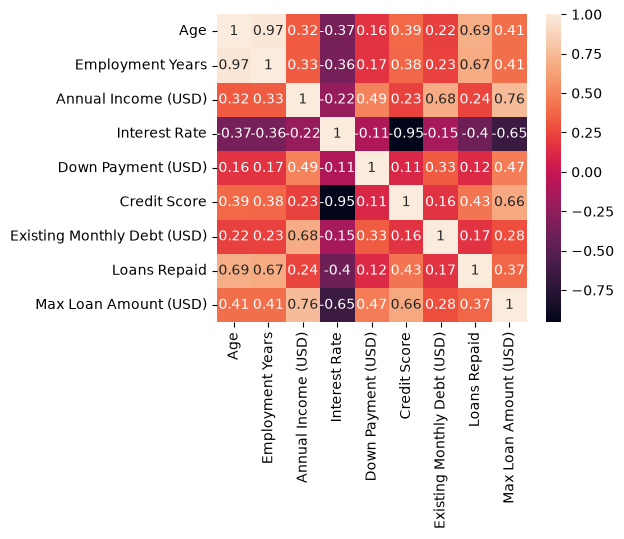

In [18]:
# Calculate the Pearson correlation matrix for numerical features and visualize it via a heatmap
plt.figure(figsize=(5, 4))
correlation_matrix = mortgage_data[numeric_cols].corr()
sns.heatmap(data=correlation_matrix, annot=True)

Correlation Insights:
- Multicollinearity Risk: Age and Employment Years are almost perfectly correlated (0.97), meaning they carry identical information. 
- Strong Credit Drivers: Max Loan Amount is strongly driven by high Annual Income (0.76) and an excellent Credit Score (0.66).
- Inverse Risk Pricing: Interest Rate has a near-perfect negative correlation with Credit Score (-0.95). This proves that the bank's pricing model strictly lowers interest rates as a borrower's credit score improves.
- Debt-to-Income Link: Existing Monthly Debt is strongly tied to Annual Income (0.68), showing that higher-income applicants inherently carry larger absolute debt lines.

<Axes: >

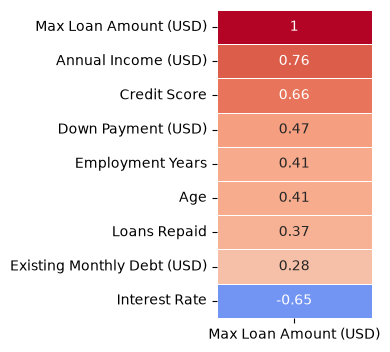

In [19]:
# Calculate correlation matrix and isolate target column correlations to identify key predictive features
correlation_matrix = mortgage_data[numeric_cols].corr()

target_col = y.name
single_corr = correlation_matrix[[target_col]].sort_values(
    by=target_col, ascending=False
)

# Plot a single-column heatmap to clearly visualize feature relationships with the target
plt.figure(figsize=(2, 4))  
sns.heatmap(
    data=single_corr,
    annot=True,  
    cmap="coolwarm",  
    vmin=-1,
    vmax=1,  
    linewidths=0.5,  
    cbar=False,  
)

Target Correlation Insights:
- Primary Positive Drivers: Annual Income (0.76) and Credit Score (0.66) have the strongest positive correlation with Max Loan Amount. This confirms that higher earnings and superior creditworthiness are the main factors unlocking larger loans.
- Secondary Enhancers: Down Payment (0.47), Employment Years (0.41), and Age (0.41) show moderate positive relationships, indicating that financial stability and longer career history further boost loan caps.
- Strong Inverse Relationship: Interest Rate shows a strong negative correlation (-0.65). This proves that applicants who qualify for the largest loan amounts are consistently rewarded with the lowest interest rates due to their low-risk profiles.

<Axes: xlabel='Max Loan Amount (USD)', ylabel='Age'>

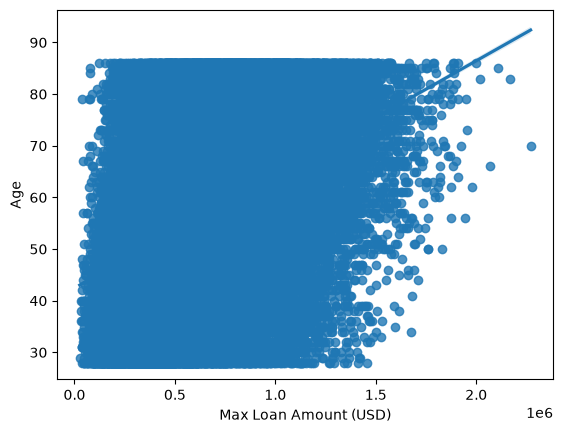

In [20]:
# Plot a regression line over a scatter plot to analyze the relationship between Age and the target variable
sns.regplot(x=y, y=mortgage_data['Age'])

The scatter plot shows a dense block of data across all age groups, confirming a weak standalone relationship between age and maximum loan amount. However, the upward-sloping trend line is driven entirely by a select group of older applicants unlocking the extreme multi-million dollar loans, while younger borrowers remain tightly capped below the 1.5 million USD threshold.

<Axes: xlabel='Max Loan Amount (USD)', ylabel='Loans Repaid'>

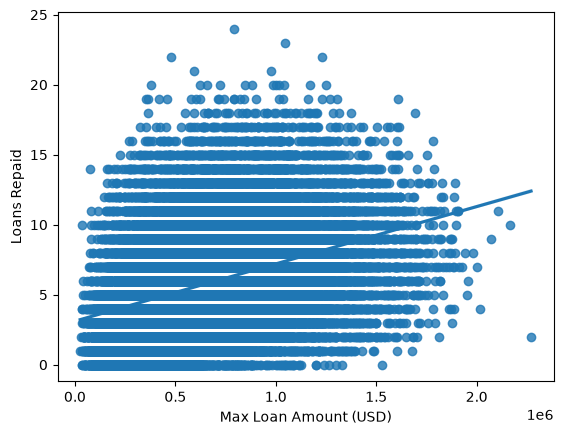

In [21]:
# Plot a regression line over a scatter plot to analyze the relationship between Loans Repaid and the target variable
sns.regplot(x=y, y=mortgage_data['Loans Repaid'])

The scatter plot demonstrates a moderate positive relationship between the number of repaid loans and the maximum approved loan amount. Interestingly, the data forms a distinct dome shape: borrowers with an exceptionally high number of past loans (above 15–20) paradoxically receive average loan limits, whereas the absolute highest funding caps (exceeding 1.5 to 2 million USD) are granted to clients with a moderate history of around 5 to 12 repaid loans.

<Axes: xlabel='Max Loan Amount (USD)', ylabel='Existing Monthly Debt (USD)'>

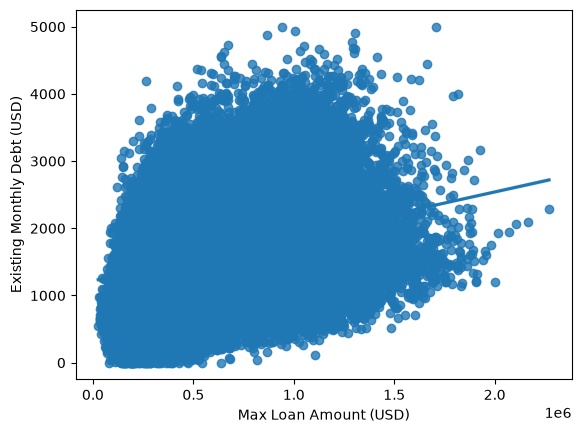

In [22]:
# Plot a regression line over a scatter plot to analyze the relationship between Existing Monthly Debt (USD) and the target variable
sns.regplot(x=y, y=mortgage_data['Existing Monthly Debt (USD)'])

The scatter plot shows a weak positive correlation between existing monthly debt and the maximum loan amount, with most applicants clustered below 1.5 million USD and 4,000 USD in monthly debt. Interestingly, the distribution narrows into a distinct funnel shape at the higher end, revealing that the elite tier of applicants securing the absolute largest loans (above 1.7 million USD) maintains a controlled, moderate debt level strictly between 1,000 and 3,000 USD.